# Maruti Suzuki On-Road Vehicle Prices Prediction

### Business Problem:

### Goal

### About Dataset

##### (Maruti Suzuki Dataset)
1. Dataset Overview
| Sales Table
Rows: 800,000
Columns: 17
| Products Table
Rows: 57
Columns: 6
| Dealers Table
Rows: 16
Columns: 4

#### libraries

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics # R^2, MSE, RMSE etc...

In [2]:
sales=pd.read_csv(r"C:\Users\Hp\Downloads\Maruti_Suzuki_Sales.csv")

In [3]:
products=pd.read_csv(r"C:\Users\Hp\Downloads\Maruti_Suzuki_Products.csv")

In [4]:
dealers=pd.read_csv(r"C:\Users\Hp\Downloads\Maruti_Suzuki_Dealers.csv")

In [5]:
np.shape(sales)

(800000, 17)

In [6]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   SaleDate               800000 non-null  object 
 1   InvoiceID              799255 non-null  object 
 2   ProductID              798430 non-null  object 
 3   FuelType               800000 non-null  object 
 4   Transmission           800000 non-null  object 
 5   Color                  800000 non-null  object 
 6   DealerCode             800000 non-null  object 
 7   Channel                800000 non-null  object 
 8   UnitsSold              800000 non-null  int64  
 9   ExShowroomPrice        800000 non-null  object 
 10  DiscountApplied        800000 non-null  int64  
 11  OnRoadPrice            800000 non-null  int64  
 12  PaymentMode            800000 non-null  object 
 13  FinancePartner         228277 non-null  object 
 14  CustomerType           800000 non-nu

In [7]:
sales.head(9)

,SaleDate,InvoiceID,ProductID,FuelType,Transmission,Color,DealerCode,Channel,UnitsSold,ExShowroomPrice,DiscountApplied,OnRoadPrice,PaymentMode,FinancePartner,CustomerType,SatisfactionScore,BookingToDeliveryDays
0,18-05-2023,GU-AMR-20230518-00001,MSZ-CIAZ-2014-001,Petrol,AMT,Beige,AMR,Arena,1,932877,15000,959148,Loan,HDFC,Individual,84.0,12.0
1,21-03-2024,KA-PRT-20240321-00001,MSZ-IGNI-2016-003,Petrol,AMT,Beige,PRT,NEXA,1,649790,5000,673433,Loan,HDFC,Fleet,90.0,7.0
2,02-10-2022,KA-PRT-20221002-00001,MSZ-JIMN-2019-003,Petrol,Automatic,Blue,PRT,NEXA,1,1678291,20000,1675155,Lease,NaN,Individual,73.0,51.0
3,18-05-2023,HA-VPL-20230518-00001,MSZ-FRON-2023-001,Petrol,CVT,Black,VPL,Arena,1,839367,20000,872974,Loan,IDFC,Individual,79.0,30.0
4,29-05-2021,TA-AMB-20210529-00001,MSZ-FR0N-2023-001,Petrol,Automatic,Black,AMB,NEXA,1,â‚¹871980,20000,895414,Lease,NaN,Individual,84.0,10.0
5,18-06-2022,TA-AMB-20220618-00001,MSZ-INVI-2021-003,Petrol Hybrid,Automatic,Blue,AMB,NEXA,1,1422565,15000,1443229,Cash,NaN,Corporate,100.0,41.0
6,15-09-2021,GU-KAT-20210915-00001,MSZ-BALE-2015-002,CNG,AMT,Red,KAT,Arena,1,914740,10000,927457,Cash,NaN,Fleet,96.0,58.0
7,17-02-2023,HA-VPL-20230217-00001,MSZ-SWIF-2005-002,Petrol,Manual,Black,VPL,NEXA,1,â‚¹734660,20000,737622,Cash,NaN,Fleet,83.0,58.0
8,12-07-2023,HA-VPL-20230712-00001,MSZ-JIMN-2019-001,Petrol,Manual,Beige,VPL,NEXA,1,1364792,25000,1397800,Lease,NaN,Corporate,91.0,32.0


In [8]:
sales.isnull().sum()

SaleDate                      0
InvoiceID                   745
ProductID                  1570
FuelType                      0
Transmission                  0
Color                         0
DealerCode                    0
Channel                       0
UnitsSold                     0
ExShowroomPrice               0
DiscountApplied               0
OnRoadPrice                   0
PaymentMode                   0
FinancePartner           571723
CustomerType                  0
SatisfactionScore          2380
BookingToDeliveryDays      1530
dtype: int64

In [9]:
sales.duplicated().sum()

np.int64(0)

In [10]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ProductID         57 non-null     object
 1   Model             57 non-null     object
 2   VariantCode       57 non-null     object
 3   Segment           57 non-null     object
 4   BasePriceVariant  57 non-null     int64 
 5   AvailableFuels    57 non-null     object
dtypes: int64(1), object(5)
memory usage: 2.8+ KB


In [11]:
np.shape(products)

(57, 6)

In [12]:
dealers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   DealerName  16 non-null     object
 1   City        16 non-null     object
 2   State       16 non-null     object
 3   DealerCode  16 non-null     object
dtypes: object(4)
memory usage: 644.0+ bytes


In [13]:
np.shape(dealers)

(16, 4)

In [14]:
# Hidden Null Cleaning
sales.replace(
    ['', 'NA', 'N/A', 'NULL',
     'null', 'nan', 'None'],
    np.nan,
    inplace=True
)

In [15]:
# Price Cleaning
sales['ExShowroomPrice'] = (sales['ExShowroomPrice'].astype(str).str.replace(r'[^0-9.]','',regex=True))
sales['ExShowroomPrice'] = pd.to_numeric( sales['ExShowroomPrice'], errors='coerce')

In [16]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   SaleDate               800000 non-null  object 
 1   InvoiceID              799255 non-null  object 
 2   ProductID              798430 non-null  object 
 3   FuelType               800000 non-null  object 
 4   Transmission           800000 non-null  object 
 5   Color                  800000 non-null  object 
 6   DealerCode             800000 non-null  object 
 7   Channel                800000 non-null  object 
 8   UnitsSold              800000 non-null  int64  
 9   ExShowroomPrice        800000 non-null  int64  
 10  DiscountApplied        800000 non-null  int64  
 11  OnRoadPrice            800000 non-null  int64  
 12  PaymentMode            800000 non-null  object 
 13  FinancePartner         228277 non-null  object 
 14  CustomerType           800000 non-nu

## data cleaning

#### ProductID Missing (1570 rows)~0.2% → HIGH PRIORITY

In [17]:
sales = sales.dropna(subset=['ProductID'])

#### 2. InvoiceID Missing (745 rows)= 0.09%

In [18]:

sales = sales.dropna(subset=['InvoiceID'])

#### 3. FinancePartner Missing (71.5%)

In [19]:
sales['FinancePartner'] = sales['FinancePartner'].fillna('No Finance')

#### 4. SatisfactionScore Missing (2380)= 0.3%

In [20]:
sales['SatisfactionScore'] = sales['SatisfactionScore'].fillna(sales['SatisfactionScore'].median())

#### 5. BookingToDeliveryDays Missing (1530)=0.19%

In [21]:
sales['BookingToDeliveryDays'] = sales['BookingToDeliveryDays'].fillna(sales['BookingToDeliveryDays'].median())

In [22]:
# Join Tables
df = ( sales.merge(products,on='ProductID',how='left')
    .merge(dealers,on='DealerCode',how='left'))


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797687 entries, 0 to 797686
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   SaleDate               797687 non-null  object 
 1   InvoiceID              797687 non-null  object 
 2   ProductID              797687 non-null  object 
 3   FuelType               797687 non-null  object 
 4   Transmission           797687 non-null  object 
 5   Color                  797687 non-null  object 
 6   DealerCode             797687 non-null  object 
 7   Channel                797687 non-null  object 
 8   UnitsSold              797687 non-null  int64  
 9   ExShowroomPrice        797687 non-null  int64  
 10  DiscountApplied        797687 non-null  int64  
 11  OnRoadPrice            797687 non-null  int64  
 12  PaymentMode            797687 non-null  object 
 13  FinancePartner         797687 non-null  object 
 14  CustomerType           797687 non-nu

In [24]:
df.isnull().sum()

SaleDate                 0
InvoiceID                0
ProductID                0
FuelType                 0
Transmission             0
Color                    0
DealerCode               0
Channel                  0
UnitsSold                0
ExShowroomPrice          0
DiscountApplied          0
OnRoadPrice              0
PaymentMode              0
FinancePartner           0
CustomerType             0
SatisfactionScore        0
BookingToDeliveryDays    0
Model                    0
VariantCode              0
Segment                  0
BasePriceVariant         0
AvailableFuels           0
DealerName               0
City                     0
State                    0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
#change date format
df['SaleDate'] = pd.to_datetime(df['SaleDate'],format='mixed',dayfirst=True)
print(df['SaleDate'].dtype)
df['SaleDate']

datetime64[ns]


0        2023-05-18
1        2024-03-21
2        2022-10-02
3        2023-05-18
4        2021-05-29
            ...    
797682   2021-04-07
797683   2024-12-08
797684   2021-03-21
797685   2024-09-22
797686   2021-10-30
Name: SaleDate, Length: 797687, dtype: datetime64[ns]

In [27]:
df['BookingToDeliveryDays'] = df['BookingToDeliveryDays'].astype(int)

### feature engineering

In [28]:
# Revenue Feature
df['Revenue'] = df['OnRoadPrice'] * df['UnitsSold']

In [29]:
#price difference feature
df['PriceDifference']=(df['OnRoadPrice']-df['ExShowroomPrice'])  

In [30]:
#discount %age
df['DiscountPercent']=(df['DiscountApplied']/df['ExShowroomPrice'])*100

In [31]:
df.head()

,SaleDate,InvoiceID,ProductID,FuelType,Transmission,Color,DealerCode,Channel,UnitsSold,ExShowroomPrice,...,VariantCode,Segment,BasePriceVariant,AvailableFuels,DealerName,City,State,Revenue,PriceDifference,DiscountPercent
0,2023-05-18,GU-AMR-20230518-00001,MSZ-CIAZ-2014-001,Petrol,AMT,Beige,AMR,Arena,1,932877,...,V1,Sedan,950000,Petrol,Amar Cars Pvt Ltd,Vadodara,Gujarat,959148,26271,1.607929
1,2024-03-21,KA-PRT-20240321-00001,MSZ-IGNI-2016-003,Petrol,AMT,Beige,PRT,NEXA,1,649790,...,V3,Hatchback,648000,Petrol,Pratham Motors,Bengaluru,Karnataka,673433,23643,0.769479
2,2022-10-02,KA-PRT-20221002-00001,MSZ-JIMN-2019-003,Petrol,Automatic,Blue,PRT,NEXA,1,1678291,...,V3,SUV,1620000,Petrol,Pratham Motors,Bengaluru,Karnataka,1675155,-3136,1.191688
3,2023-05-18,HA-VPL-20230518-00001,MSZ-FRON-2023-001,Petrol,CVT,Black,VPL,Arena,1,839367,...,V1,SUV,902500,Petrol,Vipul Motors,Gurgaon,Haryana,872974,33607,2.382748
4,2021-05-29,TA-AMB-20210529-00001,MSZ-FR0N-2023-001,Petrol,Automatic,Black,AMB,NEXA,1,871980,...,V1,SUV,902500,Petrol,Ambal Auto,Coimbatore,Tamil Nadu,895414,23434,2.293631


## Separating Categorical and Numerical columns

In [32]:
cat_col=df.dtypes[df.dtypes=="object"].index #separating num and cat
num_col=df.dtypes[df.dtypes!="object"].index

In [33]:
cat_col

Index(['InvoiceID', 'ProductID', 'FuelType', 'Transmission', 'Color',
       'DealerCode', 'Channel', 'PaymentMode', 'FinancePartner',
       'CustomerType', 'Model', 'VariantCode', 'Segment', 'AvailableFuels',
       'DealerName', 'City', 'State'],
      dtype='object')

### cat_col

In [34]:
df['Segment'].value_counts()     #Hatchback → Chhoti aur compact car, city driving ke liye best.
                                 #Sedan → Alag boot (dicky) wali comfortable aur premium car.
                                 #SUV → Badi, high-ground-clearance wali car, highways aur rough roads ke liye suitable.
                                 #MUV → Family purpose ki multi-seater (6–8 seats) car.
                                 #Van → Zyada passengers ya luggage carry karne ke liye bani vehicle.

Segment
Hatchback    335756
SUV          252716
MUV           83830
Sedan         83511
Van           41874
Name: count, dtype: int64

In [35]:
df['DealerName'].value_counts() 

DealerName
Competent Automobiles    50277
Amar Cars Pvt Ltd        50136
Pratham Motors           50085
Ambal Auto               50062
Rana Motors              50056
KTL Automobiles          49976
TR Sawhney Motors        49939
Prem Motors              49938
Kataria Automobiles      49757
Khivraj Motors           49752
DD Motors                49721
Magic Auto               49704
Varun Motors             49634
Vipul Motors             49601
Sagar Automobiles        49534
Indus Motors             49515
Name: count, dtype: int64

In [36]:
df['City'].value_counts() 

City
Delhi         249697
Bengaluru      99619
Vadodara       50136
Coimbatore     50062
Kanpur         49976
Agra           49938
Ahmedabad      49757
Chennai        49752
Hyderabad      49634
Gurgaon        49601
Kochi          49515
Name: count, dtype: int64

In [37]:
df['State'].value_counts() 

State
Delhi            249697
Uttar Pradesh     99914
Gujarat           99893
Tamil Nadu        99814
Karnataka         99619
Telangana         49634
Haryana           49601
Kerala            49515
Name: count, dtype: int64

In [38]:
df['VariantCode'].value_counts() 

VariantCode
V1    266310
V3    265704
V2    265673
Name: count, dtype: int64

In [39]:
df['FinancePartner'].value_counts() 

FinancePartner
No Finance    570099
IDFC           38131
ICICI          38007
HDFC           37997
Yes Bank       37835
Axis           37810
SBI            37808
Name: count, dtype: int64

In [40]:
df['FinancePartner'].value_counts(normalize=True)*100   

FinancePartner
No Finance    71.469010
IDFC           4.780196
ICICI          4.764651
HDFC           4.763397
Yes Bank       4.743088
Axis           4.739954
SBI            4.739704
Name: proportion, dtype: float64

In [41]:
df['Channel'].value_counts()  #Arena → Maruti ke normal/budget car showrooms.
                              #Nexa → Maruti ke premium car showrooms.

Channel
Arena    398904
NEXA     398783
Name: count, dtype: int64

In [42]:
df['Channel'].value_counts(normalize=True)*100   

Channel
Arena    50.007584
NEXA     49.992416
Name: proportion, dtype: float64

In [43]:
df['FuelType'].value_counts() 

FuelType
Petrol           502871
CNG              210319
Petrol Hybrid     84497
Name: count, dtype: int64

In [44]:
df['FuelType'].value_counts(normalize=True)*100   

FuelType
Petrol           63.041143
CNG              26.366106
Petrol Hybrid    10.592751
Name: proportion, dtype: float64

In [45]:
df['Transmission'].value_counts() #gear typ  MT → Manual Gear
                                    #AT → Fully Automatic Gear
                                    #AMT → Manual Gear + Automatic Control
                                    #CVT → No fixed gears, very smooth acceleration

Transmission
Automatic    199832
Manual       199702
CVT          199161
AMT          198992
Name: count, dtype: int64

In [46]:
df['Transmission'].value_counts(normalize=True)*100  

Transmission
Automatic    25.051430
Manual       25.035133
CVT          24.967312
AMT          24.946125
Name: proportion, dtype: float64

In [47]:
df['Color'].value_counts() 

Color
Silver    114089
Beige     114083
White     114044
Black     113992
Grey      113981
Red       113879
Blue      113619
Name: count, dtype: int64

In [48]:
df['CustomerType'].value_counts()  #CustomerType ka matlab hai car kharidne wala customer kis type ka hai.
                                    #👤 Individual → Personal use ke liye car kharidne wala.
                                    #🏢 Corporate → Company ya organization jo business ke liye car kharidti hai.
                                    #🚖 Fleet → Taxi ya rental company jo ek saath multiple cars kharidti hai.

CustomerType
Fleet         265981
Corporate     265979
Individual    265727
Name: count, dtype: int64

In [49]:
df['PaymentMode'].value_counts()    #💵 Cash → Customer ne ek hi baar me poora payment kar diya.
                                    #🏦 Loan → Customer ne bank ya finance company se loan lekar EMI me payment kiya.
                                    #📄 Lease → Customer ne lease agreement ke through car li aur fixed monthly payments kiye (ownership conditions lease agreement par depend karti hain).

PaymentMode
Cash     266826
Lease    265573
Loan     265288
Name: count, dtype: int64

In [50]:
df['Model'].value_counts().head(10)

Model
S-Presso        42475
Grand Vitara    42293
Brezza          42276
Invicto         42204
Jimny           42158
Ignis           42124
Fronx           42119
Celerio         42089
Ertiga          41943
Alto            41919
Name: count, dtype: int64

In [51]:
df['AvailableFuels'].value_counts() 

AvailableFuels
Petrol;CNG       419333
Petrol           293857
Petrol Hybrid     84497
Name: count, dtype: int64

### num_col

In [52]:
df[num_col].mean()

SaleDate                 2022-09-30 04:56:35.310692352
UnitsSold                                     1.119587
ExShowroomPrice                          882638.062858
DiscountApplied                           12508.114085
OnRoadPrice                              910108.243582
SatisfactionScore                            84.415909
BookingToDeliveryDays                         29.99736
BasePriceVariant                         882632.491817
Revenue                                 1018844.261482
PriceDifference                           27470.180724
DiscountPercent                               1.722409
dtype: object

In [53]:
df[num_col].max()

SaleDate                 2025-12-03 00:00:00
UnitsSold                                  3
ExShowroomPrice                      1733390
DiscountApplied                        25000
OnRoadPrice                          1796656
SatisfactionScore                      100.0
BookingToDeliveryDays                     60
BasePriceVariant                     1620000
Revenue                              5363283
PriceDifference                        65000
DiscountPercent                      8.08465
dtype: object

In [54]:
df[num_col].min()

SaleDate                 2020-01-04 00:00:00
UnitsSold                                  1
ExShowroomPrice                       309228
DiscountApplied                            0
OnRoadPrice                           300438
SatisfactionScore                       44.0
BookingToDeliveryDays                      0
BasePriceVariant                      332500
Revenue                               300438
PriceDifference                       -10000
DiscountPercent                          0.0
dtype: object

In [55]:
df[num_col].std()

SaleDate                 527 days 13:52:05.051398504
UnitsSold                                   0.380895
ExShowroomPrice                         362054.52397
DiscountApplied                          8545.336149
OnRoadPrice                            362468.594363
SatisfactionScore                           7.807478
BookingToDeliveryDays                      17.592089
BasePriceVariant                       360064.410653
Revenue                                550934.643106
PriceDifference                         16758.398432
DiscountPercent                             1.533731
dtype: object

In [56]:
df[num_col].median()

SaleDate                 2022-09-30 00:00:00
UnitsSold                                1.0
ExShowroomPrice                     900426.0
DiscountApplied                      15000.0
OnRoadPrice                         926822.0
SatisfactionScore                       85.0
BookingToDeliveryDays                   30.0
BasePriceVariant                    902500.0
Revenue                             952162.0
PriceDifference                      27488.0
DiscountPercent                     1.407798
dtype: object

In [57]:
df[num_col].describe().T  

,count,mean,min,25%,50%,75%,max,std
SaleDate,797687,2022-09-30 04:56:35.310692352,2020-01-04 00:00:00,2021-07-01 00:00:00,2022-09-30 00:00:00,2023-12-31 00:00:00,2025-12-03 00:00:00,NaN
UnitsSold,797687.0,1.119587,1.0,1.0,1.0,1.0,3.0,0.380895
ExShowroomPrice,797687.0,882638.062858,309228.0,527477.0,900426.0,1089023.5,1733390.0,362054.52397
DiscountApplied,797687.0,12508.114085,0.0,5000.0,15000.0,20000.0,25000.0,8545.336149
OnRoadPrice,797687.0,910108.243582,300438.0,557387.5,926822.0,1118097.0,1796656.0,362468.594363
SatisfactionScore,797687.0,84.415909,44.0,79.0,85.0,90.0,100.0,7.807478
BookingToDeliveryDays,797687.0,29.99736,0.0,15.0,30.0,45.0,60.0,17.592089
BasePriceVariant,797687.0,882632.491817,332500.0,540000.0,902500.0,1080000.0,1620000.0,360064.410653
Revenue,797687.0,1018844.261482,300438.0,607718.5,952162.0,1230131.0,5363283.0,550934.643106
PriceDifference,797687.0,27470.180724,-10000.0,14986.0,27488.0,39945.0,65000.0,16758.398432


## bivariate

#### cat-cat

In [58]:
cat_col

Index(['InvoiceID', 'ProductID', 'FuelType', 'Transmission', 'Color',
       'DealerCode', 'Channel', 'PaymentMode', 'FinancePartner',
       'CustomerType', 'Model', 'VariantCode', 'Segment', 'AvailableFuels',
       'DealerName', 'City', 'State'],
      dtype='object')

In [59]:
pd.crosstab(df['CustomerType'], df['PaymentMode'])

PaymentMode,Cash,Lease,Loan
CustomerType,,,
Corporate,88873,88575,88531
Fleet,89020,88204,88757
Individual,88933,88794,88000


In [60]:
pd.crosstab(df['Channel'], df['Segment'])

Segment,Hatchback,MUV,SUV,Sedan,Van
Channel,,,,,
Arena,167894,41948,126391,41740,20931
NEXA,167862,41882,126325,41771,20943


In [61]:
#Arena and NEXA have almost identical sales distribution.
#Hatchbacks are the most common segment.
#Vans have the lowest number of sales.

In [62]:
pd.crosstab(df['Model'], df['FuelType'])

FuelType,CNG,Petrol,Petrol Hybrid
Model,,,
Alto,21253,20666,0
Baleno,20777,20937,0
Baleno RS,0,41841,0
Brezza,0,42276,0
Celerio,21064,21025,0
Ciaz,0,41673,0
Dzire,20916,20922,0
Eeco,21021,20853,0
Ertiga,21137,20806,0


In [63]:
pd.crosstab(df['State'], df['Channel'])

Channel,Arena,NEXA
State,,
Delhi,125539,124158
Gujarat,49784,50109
Haryana,24740,24861
Karnataka,49932,49687
Kerala,24741,24774
Tamil Nadu,49790,50024
Telangana,24611,25023
Uttar Pradesh,49767,50147


### cat-num

In [64]:
cat_col

Index(['InvoiceID', 'ProductID', 'FuelType', 'Transmission', 'Color',
       'DealerCode', 'Channel', 'PaymentMode', 'FinancePartner',
       'CustomerType', 'Model', 'VariantCode', 'Segment', 'AvailableFuels',
       'DealerName', 'City', 'State'],
      dtype='object')

In [65]:
num_col

Index(['SaleDate', 'UnitsSold', 'ExShowroomPrice', 'DiscountApplied',
       'OnRoadPrice', 'SatisfactionScore', 'BookingToDeliveryDays',
       'BasePriceVariant', 'Revenue', 'PriceDifference', 'DiscountPercent'],
      dtype='object')

In [66]:
df.groupby('Model')['OnRoadPrice'].agg(['count','sum','mean','min','max']).sort_values(by='sum', ascending=False)

,count,sum,mean,min,max
Model,,,,,
Grand Vitara,42293,65201113803,1.541653e+06,1315714,1796656
Jimny,42158,65008841208,1.542029e+06,1316235,1796310
Invicto,42204,60837709562,1.441515e+06,1231992,1680969
XL6,41887,51898275933,1.239007e+06,1051463,1450063
Baleno RS,41841,47627420355,1.138295e+06,963613,1334839
Ciaz,41673,43252165749,1.037894e+06,875092,1218442
Brezza,42276,41722666016,9.869114e+05,831338,1159998
Fronx,42119,41567178809,9.868985e+05,830369,1160348
Fr0nx,41666,41136272483,9.872863e+05,832114,1160525


In [67]:
#Grand Vitara and Jimny have the highest average OnRoadPrice, making them the premium models.
# Premium vehicles generate significantly higher total sales value due to their higher selling prices.

In [68]:
df.groupby('Transmission')['OnRoadPrice'].agg(['count','sum','mean','min','max']).sort_values(by='sum', ascending=False)

,count,sum,mean,min,max
Transmission,,,,,
Automatic,199832,181895038047,910239.791660,300438,1796356
Manual,199702,181637818181,909544.311930,301154,1795959
CVT,199161,181294329014,910290.312933,301078,1796656
AMT,198992,181154329256,910359.859974,301533,1793427


In [69]:
# 1. The average OnRoadPrice is nearly identical across all transmission types (~₹9.1 lakh).
# 2. The dataset is well-balanced.
# 3. Total sales value is evenly distributed across transmission types.
# 4. Transmission has minimal influence on vehicle pricie Transmission  received a very low importance score.

In [70]:
df.groupby('AvailableFuels')[['Revenue','SatisfactionScore',
                           'DiscountApplied','OnRoadPrice']].mean().sort_values(by='OnRoadPrice', ascending=False)

,Revenue,SatisfactionScore,DiscountApplied,OnRoadPrice
AvailableFuels,,,,
Petrol Hybrid,1.666440e+06,84.440323,12520.740381,1.491637e+06
Petrol,1.170210e+06,84.427783,12536.250625,1.044741e+06
Petrol;CNG,7.822789e+05,84.402668,12485.852532,6.985817e+05


In [71]:
# 1. Petrol Hybrid vehicles have the highest average
#    OnRoadPrice and Revenue, making them premium offerings.

# 2. Petrol+CNG vehicles have the lowest average price,
#    targeting budget-conscious customers.

# 3. Customer satisfaction is consistently high across
#    all fuel types (~84.4), indicating uniform customer experience.

# 4. Discount values are nearly the same for all fuel
#    categories, suggesting a standardized discount policy.

# 5. Higher-priced Hybrid vehicles generate significantly
#    more revenue while maintaining similar satisfaction scores.

In [72]:
df.groupby('Segment')[['Revenue','ExShowroomPrice',
                           'DiscountApplied','OnRoadPrice']].mean().sort_values(by='OnRoadPrice', ascending=False)

,Revenue,ExShowroomPrice,DiscountApplied,OnRoadPrice
Segment,,,,
SUV,1.397513e+06,1.220844e+06,12529.361022,1.248333e+06
MUV,1.216225e+06,1.060208e+06,12519.205535,1.087676e+06
Sedan,1.047810e+06,9.091330e+05,12520.506281,9.366186e+05
Hatchback,7.442163e+05,6.368556e+05,12485.763471,6.643250e+05
Van,4.826410e+05,4.039279e+05,12512.179395,4.312649e+05


In [73]:
# 1. SUVs have the highest average Revenue and OnRoadPrice,
#    making them the most premium and profitable segment.

# 2. MUVs also generate high revenue and target the
#    upper-mid to premium vehicle market.

# 3. Hatchbacks and Vans are positioned as affordable
#    vehicle segments with lower average prices.

# 5. Vehicle Segment is a key factor influencing
#    pricing and overall revenue generation.

In [74]:
df.groupby('VariantCode')[['Revenue','SatisfactionScore',
                           'DiscountApplied','OnRoadPrice']].mean().sort_values(by='OnRoadPrice', ascending=False)

,Revenue,SatisfactionScore,DiscountApplied,OnRoadPrice
VariantCode,,,,
V3,1.086827e+06,84.423257,12515.336615,970746.511731
V2,1.009044e+06,84.407753,12499.633007,901718.060838
V1,9.607931e+05,84.416714,12509.368781,857978.074304


In [75]:
# 1. V3 has the highest average OnRoadPrice and Revenue,
#    making it the premium variant.

# 2. Vehicle price increases consistently from V1 to V3,
#    showing a clear premium pricing strategy.

# 3. Customer satisfaction remains almost identical across
#    all variants (~84.4).

# 4. Discount values are nearly the same, indicating a
#    standardized discount policy.

# 5. Variant selection is an important factor influencing
#    vehicle pricing and revenue generation.

In [76]:
df.groupby('Model')[['Revenue','SatisfactionScore',
                           'DiscountApplied','OnRoadPrice']].mean().sort_values(by='OnRoadPrice', ascending=False)

,Revenue,SatisfactionScore,DiscountApplied,OnRoadPrice
Model,,,,
Jimny,1.732627e+06,84.388515,12526.210921,1.542029e+06
Grand Vitara,1.724830e+06,84.422174,12515.782754,1.541653e+06
Invicto,1.607926e+06,84.458511,12525.708464,1.441515e+06
XL6,1.385195e+06,84.409220,12472.127390,1.239007e+06
Baleno RS,1.273788e+06,84.459979,12501.254750,1.138295e+06
Ciaz,1.162346e+06,84.438293,12568.089650,1.037894e+06
Fr0nx,1.103604e+06,84.406182,12477.919647,9.872863e+05
Brezza,1.104904e+06,84.401102,12605.733750,9.869114e+05
Fronx,1.107028e+06,84.460695,12524.039032,9.868985e+05


In [77]:
# 1. Premium models such as Jimny, Grand Vitara, and Invicto generate the highest average revenue.
# 2. Alto generates the lowest revenue, reflecting its positioning as an affordable entry-level vehicle.

# 3. Customer satisfaction remains consistently high
#    across all vehicle models (~84.4).

# 4. Discount values are nearly identical across models,
#    indicating a standardized discount strategy.

# 5. Revenue increases with higher OnRoadPrice,
#    showing a strong positive relationship between
#    selling price and revenue generation.

In [78]:
df.groupby('PaymentMode')['OnRoadPrice'].agg(['count','sum','mean','min','max']).sort_values(by='sum', ascending=False)

,count,sum,mean,min,max
PaymentMode,,,,,
Cash,266826,242827195899,910058.224832,301078,1796310
Loan,265288,241807455408,911490.362956,301533,1796356
Lease,265573,241346863191,908777.862173,300438,1796656


In [79]:
# 1. Loan purchases have a slightly higher average
#    vehicle price, but the difference is minimal.

# 2. The dataset is well-balanced across payment modes,
#    reducing the risk of model bias

In [80]:
df.groupby('CustomerType')['Revenue'].agg(['count','sum','mean','min','max']).sort_values(by='sum', ascending=False)

,count,sum,mean,min,max
CustomerType,,,,,
Individual,265727,271169921976,1.020483e+06,301533,5302272
Fleet,265981,270997300572,1.018860e+06,300438,5363283
Corporate,265979,270551599861,1.017192e+06,301154,5323092


In [81]:
# Individual customers contribute the highest average revenue.
# Fleet and Corporate customers show similar revenue performance.
# Balanced customer counts reduce bias in the analysis.

In [82]:
df.groupby('DealerName')['Revenue'].agg(['count','sum','mean','min','max']).sort_values(by='sum', ascending=False)

,count,sum,mean,min,max
DealerName,,,,,
Competent Automobiles,50277,51222325557,1.018802e+06,301876,5291556
Rana Motors,50056,51083541752,1.020528e+06,300438,5253813
Pratham Motors,50085,51036333853,1.018994e+06,304960,5174958
Ambal Auto,50062,51030369271,1.019343e+06,306038,5284266
Prem Motors,49938,51026312141,1.021793e+06,305735,5295378
Amar Cars Pvt Ltd,50136,50935676896,1.015950e+06,308469,5235726
TR Sawhney Motors,49939,50814536285,1.017532e+06,301154,5268222
KTL Automobiles,49976,50804225825,1.016572e+06,301533,5275737
Khivraj Motors,49752,50694141782,1.018937e+06,304392,5363283


In [83]:
# Competent Automobiles generated the highest total revenue.
# Prem Motors recorded the highest average revenue per sale.
# All dealers have nearly equal sales volume.
# Dealer-wise revenue differences are minimal, indicating balanced performance.

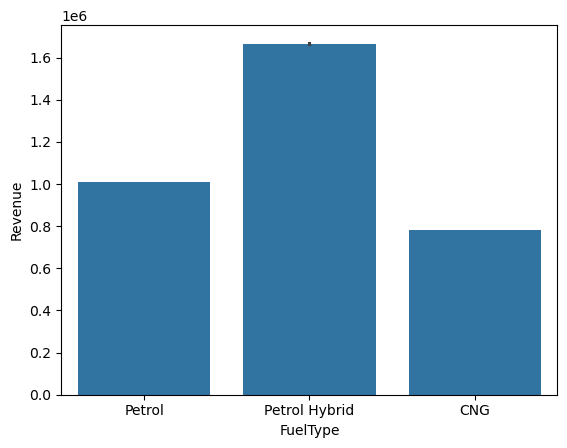

In [84]:
sns.barplot(x='FuelType',y='Revenue',data=df)
plt.show()

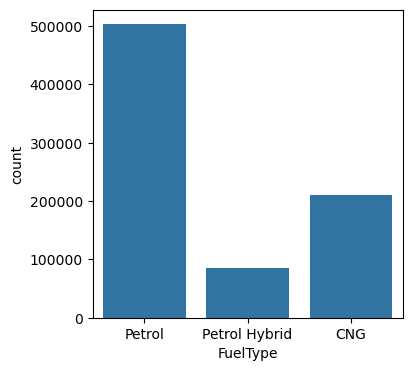

In [85]:
plt.figure(figsize=(4,4))

sns.countplot(data=df,x='FuelType')

plt.show()

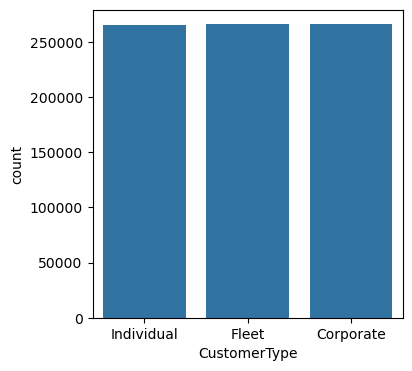

In [86]:
plt.figure(figsize=(4,4))
sns.countplot(data=df,x='CustomerType')
plt.show()

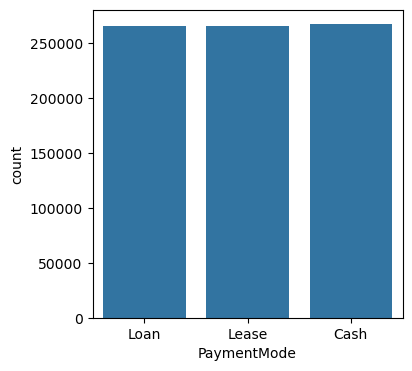

In [87]:
plt.figure(figsize=(4,4))

sns.countplot(data=df,x='PaymentMode')

plt.show()

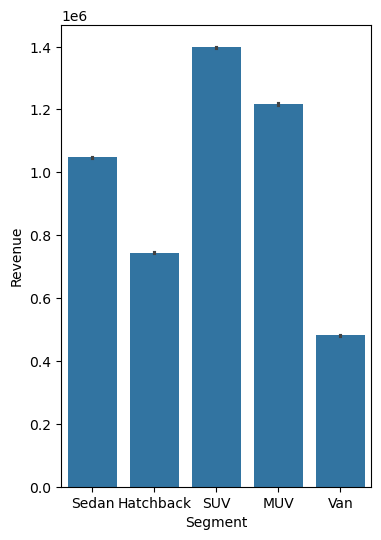

In [88]:
plt.figure(figsize=(4,6))
sns.barplot(
data=df,
x='Segment',
y='Revenue',
estimator=np.mean)
plt.show()

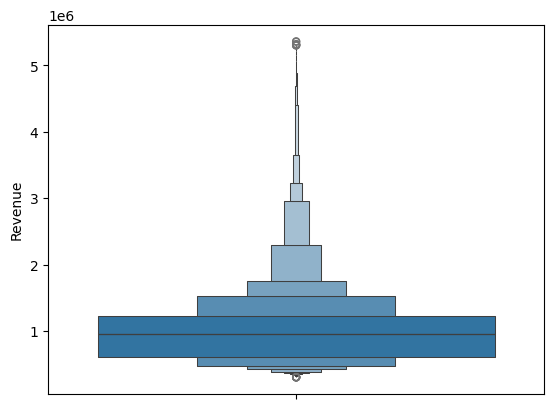

In [89]:
sns.boxenplot(data=df, y="Revenue")
plt.show()

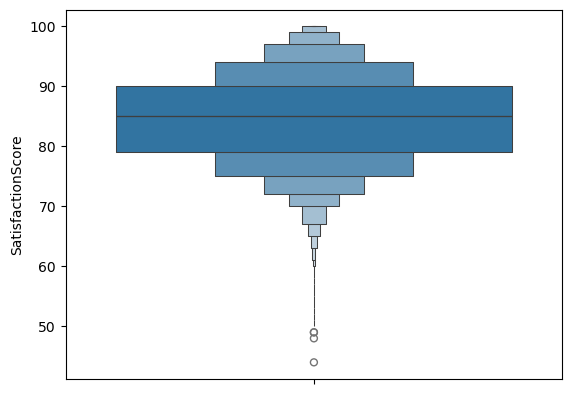

In [90]:
sns.boxenplot(data=df, y="SatisfactionScore")
plt.show()

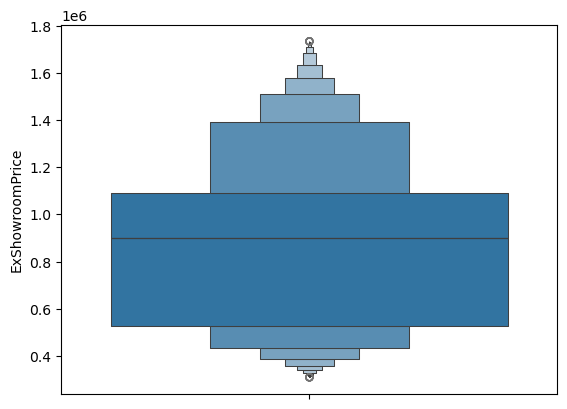

In [91]:
sns.boxenplot(data=df, y="ExShowroomPrice")
plt.show()

### num-num

In [92]:
num_col

Index(['SaleDate', 'UnitsSold', 'ExShowroomPrice', 'DiscountApplied',
       'OnRoadPrice', 'SatisfactionScore', 'BookingToDeliveryDays',
       'BasePriceVariant', 'Revenue', 'PriceDifference', 'DiscountPercent'],
      dtype='object')

In [93]:
df[num_col].corr().T

,SaleDate,UnitsSold,ExShowroomPrice,DiscountApplied,OnRoadPrice,SatisfactionScore,BookingToDeliveryDays,BasePriceVariant,Revenue,PriceDifference,DiscountPercent
SaleDate,1.000000,0.001030,0.001396,0.001303,0.001363,-0.000279,0.000022,0.001469,0.001820,-0.000680,0.000641
UnitsSold,0.001030,1.000000,-0.000745,-0.000006,-0.000732,-0.000552,-0.000855,-0.000758,0.628102,0.000248,-0.000174
ExShowroomPrice,0.001396,-0.000745,1.000000,0.001124,0.998931,0.000829,-0.000693,0.994320,0.735439,0.001579,-0.485242
DiscountApplied,0.001303,-0.000006,0.001124,1.000000,-0.022430,0.000856,0.000779,0.001070,-0.016037,-0.509415,0.766362
OnRoadPrice,0.001363,-0.000732,0.998931,-0.022430,1.000000,0.000786,-0.000716,0.993253,0.736236,0.047811,-0.502807
SatisfactionScore,-0.000279,-0.000552,0.000829,0.000856,0.000786,1.000000,-0.000430,0.000779,0.000361,-0.000900,0.000083
BookingToDeliveryDays,0.000022,-0.000855,-0.000693,0.000779,-0.000716,-0.000430,1.000000,-0.000450,-0.001173,-0.000503,0.000626
BasePriceVariant,0.001469,-0.000758,0.994320,0.001070,0.993253,0.000779,-0.000450,1.000000,0.731188,0.001505,-0.484320
Revenue,0.001820,0.628102,0.735439,-0.016037,0.736236,0.000361,-0.001173,0.731188,1.000000,0.035405,-0.370187
PriceDifference,-0.000680,0.000248,0.001579,-0.509415,0.047811,-0.000900,-0.000503,0.001505,0.035405,1.000000,-0.391901


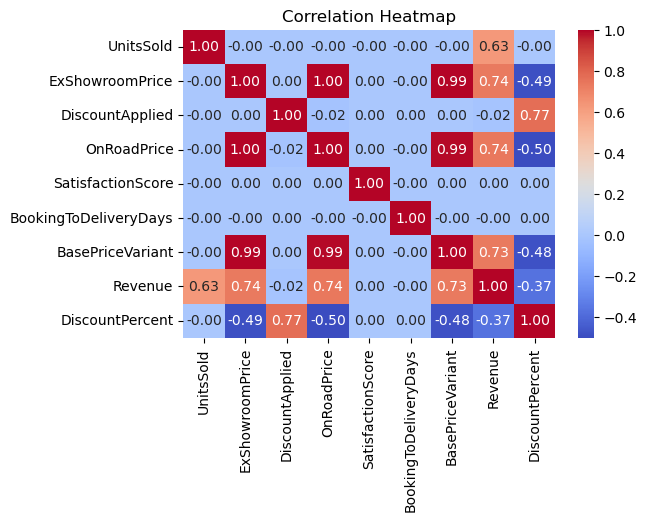

In [94]:
x= ['UnitsSold', 'ExShowroomPrice', 'DiscountApplied', 'OnRoadPrice',
       'SatisfactionScore', 'BookingToDeliveryDays', 'BasePriceVariant','Revenue','DiscountPercent']
corr = df[x].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [95]:
# 1. ExShowroomPrice (1.00) and BasePriceVariant (0.99)show an almost perfect positive correlation with
#  OnRoadPrice, indicating multicollinearity.

# 2. Revenue has a strong positive correlation (0.74) with OnRoadPrice, as higher-priced vehicles
#  generate higher revenue.

# 3. UnitsSold is positively correlated (0.63) with Revenue, indicating that increased sales volume
#    contributes to higher revenue.

# 4. DiscountApplied and DiscountPercent have a strong positive correlation (0.77), as both represent
#    discount-related information.

# 5. DiscountPercent has a moderate negative correlation(-0.50) with OnRoadPrice, suggesting that higher
#    discount percentages are associated with lower final selling prices.

# 6. SatisfactionScore and BookingToDeliveryDays show almost no linear relationship with price-related variables.

# 7. Highly correlated features such as ExShowroomPrice, BasePriceVariant, Revenue, and PriceDifference were
# excluded during model building to reduce redundancy and avoid target-related information influencing the predictions.

### Outlier

In [96]:
num_cols = ['UnitsSold', 'ExShowroomPrice', 'DiscountApplied', 'OnRoadPrice',
       'SatisfactionScore', 'BookingToDeliveryDays', 'BasePriceVariant','Revenue', 'DiscountPercent']
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_summary[col] = len(outliers)

outlier_summary

{'UnitsSold': 79521,
 'ExShowroomPrice': 0,
 'DiscountApplied': 0,
 'OnRoadPrice': 0,
 'SatisfactionScore': 2315,
 'BookingToDeliveryDays': 0,
 'BasePriceVariant': 0,
 'Revenue': 28255,
 'DiscountPercent': 34352}

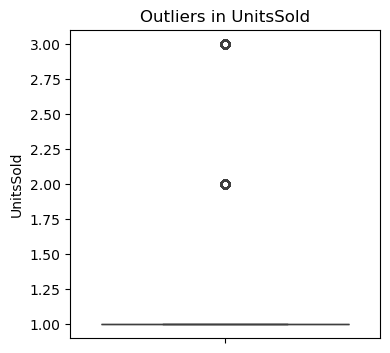

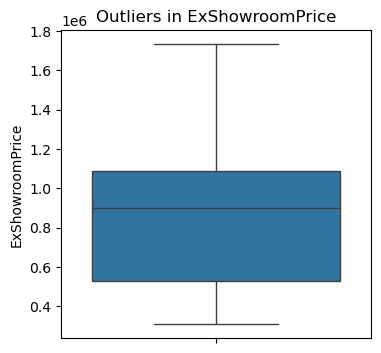

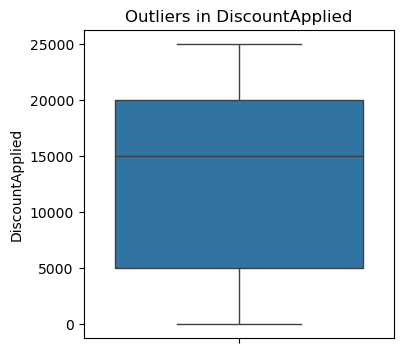

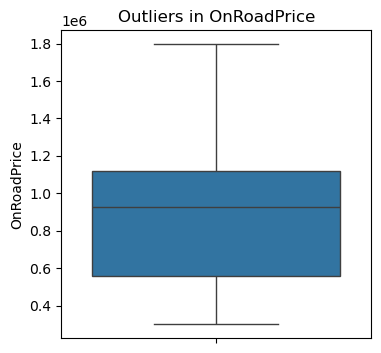

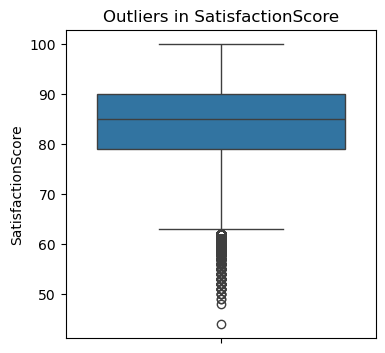

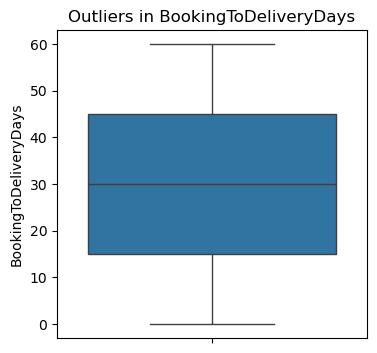

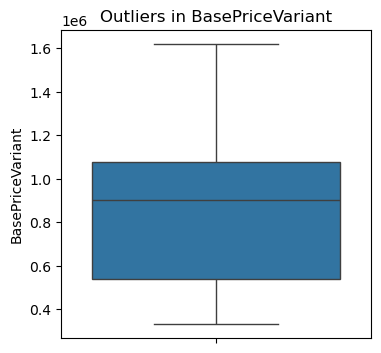

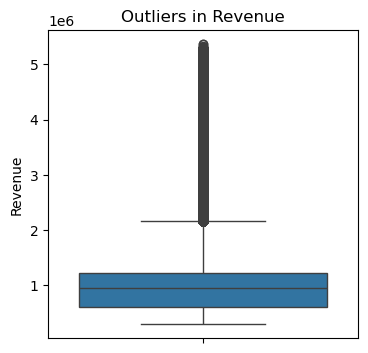

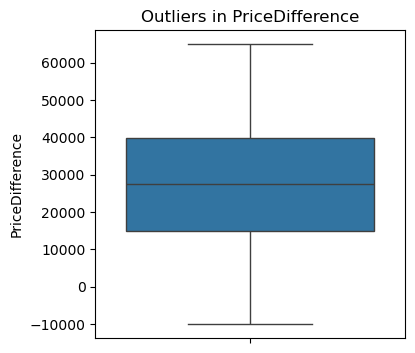

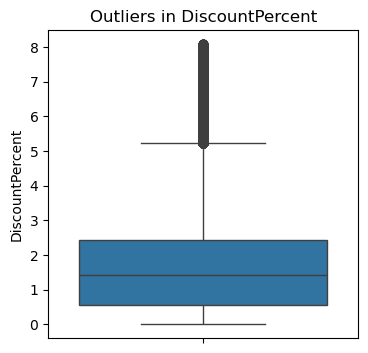

In [97]:
num_col = df.select_dtypes(
    include=['int64','float64']).columns

for col in num_col:

    plt.figure(figsize=(4,4))

    sns.boxplot(
        y=df[col])

    plt.title(f'Outliers in {col}')
    plt.show()

In [98]:
df['SatisfactionScore'].describe()

count    797687.000000
mean         84.415909
std           7.807478
min          44.000000
25%          79.000000
50%          85.000000
75%          90.000000
max         100.000000
Name: SatisfactionScore, dtype: float64

In [99]:
# SatisfactionScore outliers were retained.
# Low satisfaction ratings represent genuine customer feedback
# and are valuable for identifying areas of service improvement.

In [100]:
df['DiscountPercent'].describe()

count    797687.000000
mean          1.722409
std           1.533731
min           0.000000
25%           0.555303
50%           1.407798
75%           2.425781
max           8.084650
Name: DiscountPercent, dtype: float64

In [101]:
# Insight:
# IQR detected outliers in DiscountPercent, but since the maximum discount is only 8.08%,
# these represent valid business observations. Hence, no outlier treatment was performed.
#"IQR method ne 34,352 rows ko statistical outliers identify kiya kyunki unka DiscountPercent 5.23% se zyada tha. 
#Lekin maximum discount sirf 8.08% tha, jo automobile industry me realistic promotional discount hai.
#Isliye ye data errors nahi the, balki valid business observations the. Maine inhe retain kiya taaki valuable business information preserve rahe."

In [102]:
num_cols = [
    'ExShowroomPrice',
    'OnRoadPrice',
    'DiscountApplied',
    'SatisfactionScore',
    'BookingToDeliveryDays',
    'BasePriceVariant',
    'PriceDifference',
    'DiscountPercent','Revenue','UnitsSold'
]

df[num_cols].head()

,ExShowroomPrice,OnRoadPrice,DiscountApplied,SatisfactionScore,BookingToDeliveryDays,BasePriceVariant,PriceDifference,DiscountPercent,Revenue,UnitsSold
0,932877,959148,15000,84.0,12,950000,26271,1.607929,959148,1
1,649790,673433,5000,90.0,7,648000,23643,0.769479,673433,1
2,1678291,1675155,20000,73.0,51,1620000,-3136,1.191688,1675155,1
3,839367,872974,20000,79.0,30,902500,33607,2.382748,872974,1
4,871980,895414,20000,84.0,10,902500,23434,2.293631,895414,1


In [103]:
# Calculate Skewness
skewness = df[num_cols].skew()

skew_df = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values})

skew_df.sort_values(by='Skewness', ascending=False)

,Feature,Skewness
9,UnitsSold,3.351625
8,Revenue,2.102997
7,DiscountPercent,1.202917
0,ExShowroomPrice,0.303234
1,OnRoadPrice,0.302143
5,BasePriceVariant,0.283732
6,PriceDifference,0.000385
4,BookingToDeliveryDays,0.000320
2,DiscountApplied,-0.001864
3,SatisfactionScore,-0.140116


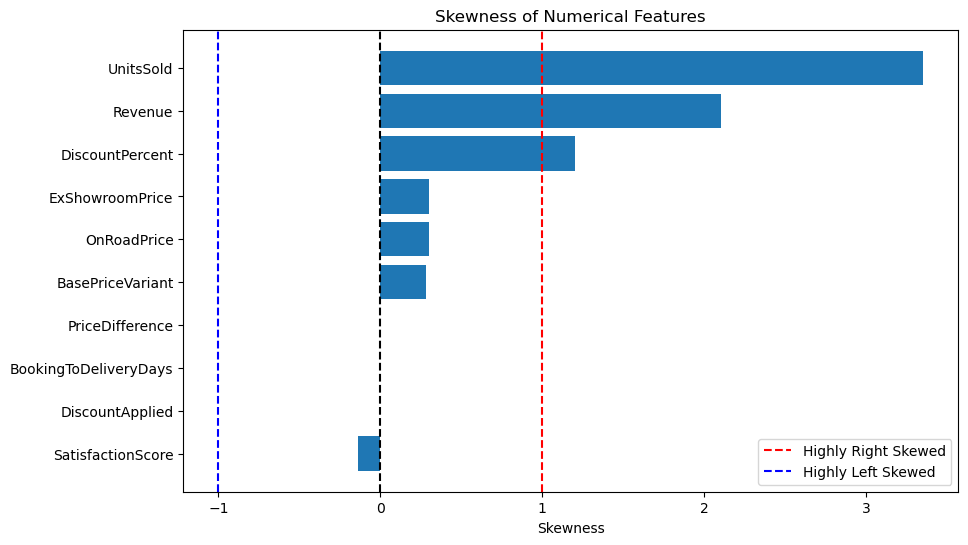

In [104]:
skew = df.select_dtypes(include=['int64','float64']).skew().sort_values()
plt.figure(figsize=(10,6))
plt.barh(skew.index, skew.values)
plt.axvline(0, color='black', linestyle='--')
plt.axvline(1, color='red', linestyle='--', label='Highly Right Skewed')
plt.axvline(-1, color='blue', linestyle='--', label='Highly Left Skewed')

plt.title("Skewness of Numerical Features")
plt.xlabel("Skewness")
plt.legend()

plt.show()

In [105]:
# Overall Insight:
# Most numerical features are approximately symmetric (Skewness between -0.5 and 0.5),
# indicating a well-balanced dataset. Only Revenue and DiscountPercent are highly right-skewed,
# which is expected due to a few high-value transactions and larger discounts. Since the final models
# are Decision Tree and Random Forest, no skewness transformation was required because tree-based
# algorithms are robust to skewed data.
# DiscountPercent (Skewness = 1.20) is also highly right-skewed, showing that higher discounts were offered only in a limited number of sales.
# SatisfactionScore (Skewness = -0.14) is approximately symmetric with a slight left skew, indicating customer satisfaction scores are fairly balanced.
# UnitsSold (3.35) is highly positively skewed,indicating that a small number of observations have exceptionally high sales volumes.

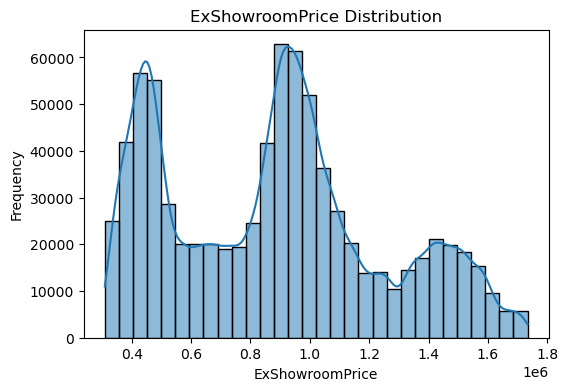

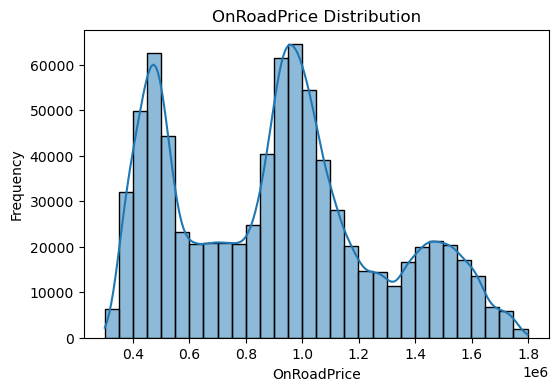

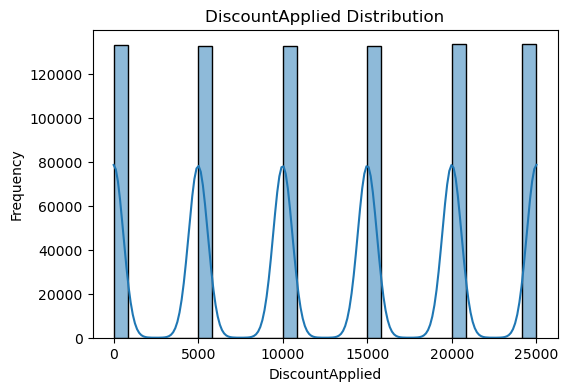

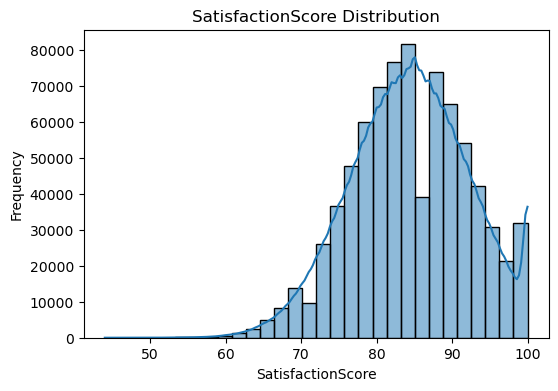

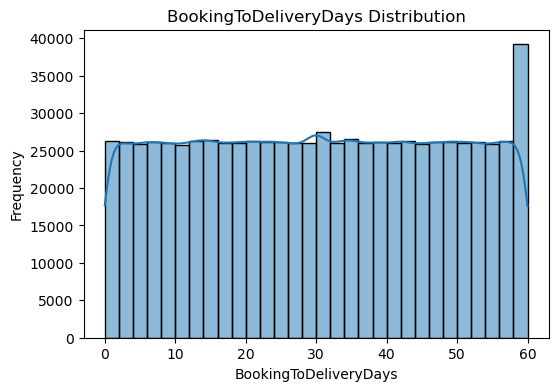

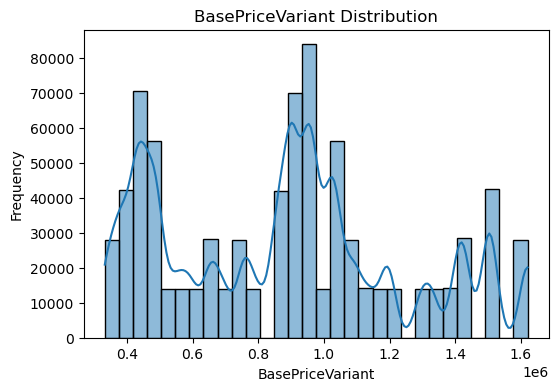

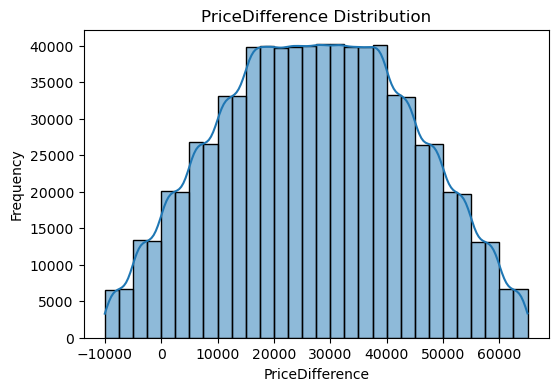

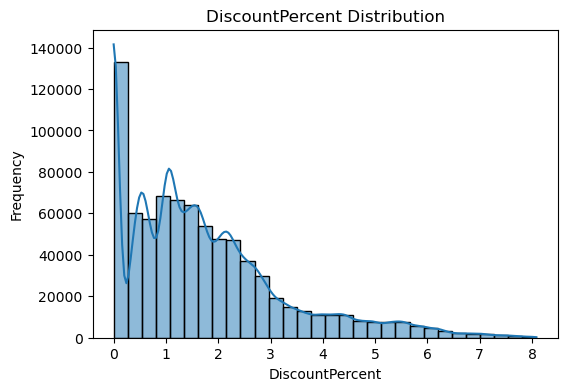

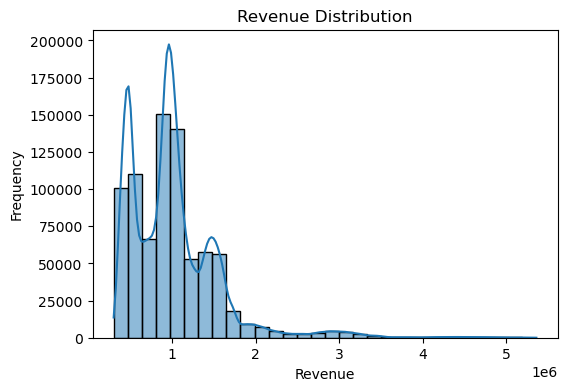

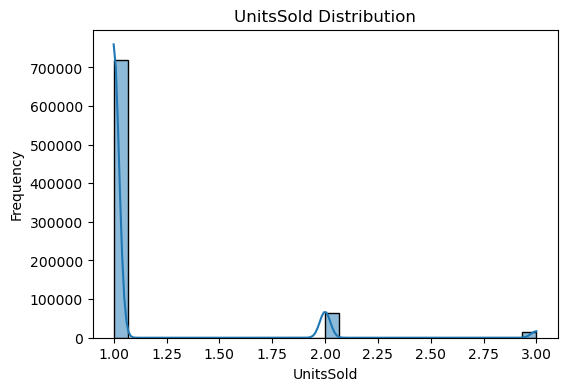

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [107]:
high_skew = skew_df[abs(skew_df['Skewness']) > 1]

print(high_skew)

           Feature  Skewness
7  DiscountPercent  1.202917
8          Revenue  2.102997
9        UnitsSold  3.351625


In [108]:

# Features with skewness greater than +1 or less than -1 are highly skewed.
# Price-related variables may naturally show right skewness due to premium vehicle models.
# Since Decision Tree and Random Forest are tree-based algorithms,
# no skewness transformation was applied in this project.

### feature engineering

In [109]:
df['Delivery_Status'] = np.where(df['BookingToDeliveryDays']>30,
    'Delayed','On Time')

In [110]:
df['Year'] = df['SaleDate'].dt.year
df['Month'] = df['SaleDate'].dt.month
df['Day'] = df['SaleDate'].dt.day
df['Quarter'] = df['SaleDate'].dt.quarter
df['DayOfWeek'] = df['SaleDate'].dt.day_name()

In [111]:
df.drop('SaleDate', axis=1, inplace=True)

In [112]:
#discount %age
df['DiscountPercent']=(df['DiscountApplied']/df['ExShowroomPrice'])*100

### insights

In [113]:
# Pricing variables are highly correlated (>0.99).
# Discounts have minimal impact on vehicle pricing.
# Customer satisfaction is high (Avg: 84.4/100).
# Satisfaction is not significantly affected by delivery time.
# UnitsSold shows no strong relationship with other variables.
# ProductID missing records were removed.
# FinancePartner nulls were treated as 'No Finance'.
# SatisfactionScore and DeliveryDays nulls were imputed using median.
# Outliers in UnitsSold and SatisfactionScore were retained as valid business observations.
# Dataset is clean, consistent, and suitable for business analysis.

In [114]:
df['UnitsSold'].value_counts().sort_index()

UnitsSold
1    718166
2     63649
3     15872
Name: count, dtype: int64

## model development

In [115]:
df.drop(columns=['InvoiceID'],inplace=True,errors='ignore')

#### label encoding

In [116]:
le = LabelEncoder()
cat_col = df.select_dtypes(include='object').columns
for col in cat_col:
    df[col] = le.fit_transform(df[col])

In [117]:
df.head()

,ProductID,FuelType,Transmission,Color,DealerCode,Channel,UnitsSold,ExShowroomPrice,DiscountApplied,OnRoadPrice,...,State,Revenue,PriceDifference,DiscountPercent,Delivery_Status,Year,Month,Day,Quarter,DayOfWeek
0,15,1,0,0,1,0,1,932877,15000,959148,...,1,959148,26271,1.607929,1,2023,5,18,2,4
1,38,1,0,0,10,1,1,649790,5000,673433,...,3,673433,23643,0.769479,1,2024,3,21,1,4
2,44,1,1,2,10,1,1,1678291,20000,1675155,...,3,1675155,-3136,1.191688,0,2022,10,2,4,3
3,30,1,2,1,15,0,1,839367,20000,872974,...,2,872974,33607,2.382748,1,2023,5,18,2,4
4,27,1,1,1,0,1,1,871980,20000,895414,...,5,895414,23434,2.293631,1,2021,5,29,2,2


#### Define target and features

In [118]:
x = df.drop(columns=[
    'Revenue',
    'OnRoadPrice',
    'DiscountApplied',
    'UnitsSold',
    'InvoiceID',
    'ProductID',
    'ExShowroomPrice',    # Remove
    'DiscountApplied',    # Remove
    'BasePriceVariant',
     'PriceDifference',
    'DiscountPercent',
    'Profit',
    'DealerCode',
    'Day'], errors='ignore')

y = df['OnRoadPrice']

#### Train-Test Split

In [119]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)

#### train model

In [120]:
model0=LinearRegression()
model0.fit(x_train, y_train)

LinearRegression()

### Model Score

In [121]:
model0.score(x_train, y_train)

0.44755705073251995

In [122]:
model0.score(x_test, y_test) # R^2 model is generalzed

0.4506200974479012

In [123]:
#Linear Regression
#Lowest R² (45.06%)
#Highest prediction error
#Couldn't capture the complex relationship between vehicle features and price.
#Suitable only as a baseline model.

In [124]:
print(x.columns.tolist())

['FuelType', 'Transmission', 'Color', 'Channel', 'PaymentMode', 'FinancePartner', 'CustomerType', 'SatisfactionScore', 'BookingToDeliveryDays', 'Model', 'VariantCode', 'Segment', 'AvailableFuels', 'DealerName', 'City', 'State', 'Delivery_Status', 'Year', 'Month', 'Quarter', 'DayOfWeek']


### evaluation model

In [125]:
pred_train=model0.predict(x_train)
pred_test=model0.predict(x_test)

#### Compare Actual vs Predicted Values

In [126]:
train_result = pd.DataFrame({ "Actual": y_train,"Predicted": pred_train.round(0).astype(int)})
print(train_result.head()) #train result

        Actual  Predicted
757351  495273     725126
341552  985639    1088771
525062  828846     714867
16090   478084     871240
552877  681227    1059223


In [127]:
test_result = pd.DataFrame({ "Actual": y_test,"Predicted": pred_test.round(0).astype(int)})
print(test_result.head())  #test results

         Actual  Predicted
495893   427810     897100
510589  1247852     786340
397406  1599959    1236224
687572   441046     724233
615408  1333260    1225166


#### train metrics

In [128]:
print("MAE :", metrics.mean_absolute_error(y_train, pred_train))
print("MSE :", metrics.mean_squared_error(y_train, pred_train))
print("RMSE :", np.sqrt(metrics.mean_squared_error(y_train, pred_train)))
print("MAPE :", metrics.mean_absolute_percentage_error(y_train, pred_train))

MAE : 226405.19985510674
MSE : 72586754846.65599
RMSE : 269419.29189769615
MAPE : 0.3039586307325031


#### test metrics

In [129]:
print("MAE :", metrics.mean_absolute_error(y_test, pred_test))
print("MSE :", metrics.mean_squared_error(y_test, pred_test))
print("RMSE :", np.sqrt(metrics.mean_squared_error(y_test, pred_test)))
print("MAPE :", metrics.mean_absolute_percentage_error(y_test, pred_test))

MAE : 225458.27865056656
MSE : 72159246695.86092
RMSE : 268624.7321001194
MAPE : 0.3037899429784907


In [130]:
#Overall Model Insights
# The training and testing metrics (MAE, RMSE, and MAPE) are
# almost identical, indicating that the model has generalized
# well and is not suffering from overfitting.

# The R² score of approximately 45% indicates that the model
# explains around 45% of the variation in OnRoadPrice.

# The average prediction error (MAE) is approximately ₹225,000,
# while the RMSE is around ₹269,000, suggesting that some
# predictions have relatively large errors.

# The MAPE of approximately 30% indicates that the model's
# predictions differ from the actual values by about 30% on average.


In [131]:
# Conclusion:
# Linear Regression provides a good baseline model and shows
# consistent performance on both training and testing datasets.
# However, it is unable to capture the complex non-linear
# relationships present in vehicle pricing. Therefore, more
# advanced models such as Decision Tree and Random Forest are
# expected to achieve better predictive performance.

In [132]:
# Train aur Test metrics (MAE, RMSE, MAPE) almost same hain,
# isse pata chalta hai ki model overfit nahi hua aur unseen data
# par bhi consistent performance de raha hai.

# R² Score lagbhag 45% hai, matlab model OnRoadPrice ki
# sirf 45% variation explain kar pa raha hai.

# Average prediction error (MAE) lagbhag ₹2.25 lakh hai,
# aur RMSE ₹2.68 lakh hai, jo batata hai ki kuch observations
# me prediction error kaafi zyada hai.

# MAPE lagbhag 30% hai, yani model ki prediction average
# 30% tak actual value se differ karti hai.

# Conclusion:
# Linear Regression baseline model ke roop me theek perform kar raha hai,
# lekin vehicle pricing ke complex aur non-linear relationships ko
# completely capture nahi kar pa raha.

# Better accuracy ke liye Decision Tree, Random Forest aur
# Gradient Boosting jaise non-linear models use karna
# zyada suitable rahega.

### Create Decision Tree Model

In [133]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import metrics
from sklearn.metrics import r2_score

#### Initialize Decision Tree with selected hyperparameters

In [134]:
dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42)

#### Train the Model
Model learns the relationship between features and target

In [135]:
dt_model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

#### Check Train and Test R² Score

In [136]:
train_score = dt_model.score(x_train, y_train)
print("Train R² :", train_score)

Train R² : 0.9866800955853927


In [137]:
test_score = dt_model.score(x_test, y_test)
print("Test R² :", test_score)

Test R² : 0.9864595386498679


#### Generate Predictions
 Predict OnRoadPrice for both training and testing data

In [138]:
pred_train_dt = dt_model.predict(x_train)
pred_test_dt = dt_model.predict(x_test)

#### Compare Actual vs Predicted Values

In [139]:
train_result = pd.DataFrame({ "Actual": y_train, "Predicted": pred_train_dt.round().astype(int)})
print(train_result.head())

        Actual  Predicted
757351  495273     478006
341552  985639    1053695
525062  828846     783751
16090   478084     477190
552877  681227     627714


In [140]:
test_result = pd.DataFrame({ "Actual": y_test, "Predicted": pred_test_dt.round().astype(int)})
print(test_result.head())

         Actual  Predicted
495893   427810     406686
510589  1247852    1331073
397406  1599959    1644412
687572   441046     477190
615408  1333260    1362089


#### Training Metrics
Evaluate model performance on training data

In [141]:
print("MAE :", metrics.mean_absolute_error(y_train, pred_train_dt))
print("MSE :", metrics.mean_squared_error(y_train, pred_train_dt))
print("RMSE :", np.sqrt(metrics.mean_squared_error(y_train, pred_train_dt)))
print("MAPE :", metrics.mean_absolute_percentage_error(y_train, pred_train_dt))

MAE : 33484.03165502321
MSE : 1750133000.3505251
RMSE : 41834.59095474133
MAPE : 0.03809631733832024


#### Testing Metrics
 Evaluate model performance on unseen data

In [142]:
print("MAE :", metrics.mean_absolute_error(y_test, pred_test_dt))
print("MSE :", metrics.mean_squared_error(y_test, pred_test_dt))
print("RMSE :", np.sqrt(metrics.mean_squared_error(y_test, pred_test_dt)))
print("MAPE :", metrics.mean_absolute_percentage_error(y_test, pred_test_dt))

MAE : 33664.129654186094
MSE : 1778495147.7129986
RMSE : 42172.20823851887
MAPE : 0.03827511005750269


In [143]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": dt_model.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
12,AvailableFuels,5.086547e-01
9,Model,3.847542e-01
11,Segment,8.689602e-02
10,VariantCode,1.955398e-02
7,SatisfactionScore,2.463207e-05
8,BookingToDeliveryDays,2.437683e-05
2,Color,1.285021e-05
18,Month,1.272938e-05
13,DealerName,9.900927e-06
20,DayOfWeek,8.217812e-06


In [144]:
# ===========================
# Decision Tree Model Insights
# ===========================

# Train R² = 0.9866 and Test R² = 0.9864 indicate excellent model performance.
# The very small gap between Train and Test R² (~0.02%) shows that the model generalizes well and is not overfitting.
# MAE = 33,670 means the predicted On-Road Price differs from the actual price by about ₹33.7K on average.
# RMSE = 42,178 indicates that larger prediction errors are also relatively low.
# MAPE = 3.83% means the model's predictions are approximately 96.17% accurate on average.
# Decision Tree successfully captured the non-linear relationship between vehicle features and On-Road Price.
# This model performs significantly better than Linear Regression, making it a strong candidate for price prediction.
# Most prediction errors are relatively small, indicating that
# the Decision Tree model has successfully learned the underlying
# pricing patterns.

In [145]:
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import r2_score

### Create Random Forest Model

In [146]:
rf = RandomForestRegressor(
    n_estimators=200,     #200 trees will be created.
    max_depth=15,         #The tree cannot grow beyond 15 levels. prevent overfitting
    min_samples_split=5,  #A node will split only if it contains at least 5 samples.
    min_samples_leaf=2,   #Every leaf node must contain at least 2 samples.
                          #This prevents the model from creating tiny leaf nodes that memorize the training data.
    random_state=42,      #Setting random_state=42 ensures that you get the same results every time you run the code.
    n_jobs=-1)            #This tells Random Forest to use all available CPU cores during training. This makes training much faster.

#### Train the Model

In [147]:
rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

#### Check Train and Test R² Score

In [148]:
print("Train R² :", rf.score(x_train, y_train))

Train R² : 0.9887976075841255


In [149]:
print("Test R² :", rf.score(x_test, y_test))

Test R² : 0.9865214305939769


#### Generate Predictions

In [150]:
pred_train_rf = rf.predict(x_train)
pred_test_rf = rf.predict(x_test)

#### Compare Actual vs Predicted Values

In [151]:
train_result = pd.DataFrame({"Actual": y_train,"Predicted": pred_train_rf.round().astype(int)})
print("Training Predictions")
print(train_result.head())

Training Predictions
        Actual  Predicted
757351  495273     477698
341552  985639    1050212
525062  828846     784954
16090   478084     476067
552877  681227     631001


In [152]:
test_result = pd.DataFrame({"Actual": y_test,"Predicted": pred_test_rf.round().astype(int)})
print("\nTesting Predictions")
print(test_result.head())


Testing Predictions
         Actual  Predicted
495893   427810     406265
510589  1247852    1331666
397406  1599959    1648587
687572   441046     478664
615408  1333260    1359707


#### Training Performance Metrics

In [153]:
print("MAE :", metrics.mean_absolute_error(y_train, pred_train_rf))
print("MSE :", metrics.mean_squared_error(y_train, pred_train_rf))
print("RMSE :", np.sqrt(metrics.mean_squared_error(y_train, pred_train_rf)))
print("MAPE :", metrics.mean_absolute_percentage_error(y_train, pred_train_rf))

MAE : 30948.305887780796
MSE : 1471908208.9206138
RMSE : 38365.45593265658
MAPE : 0.03556786332738007


#### Testing Performance Metrics

In [154]:
print("MAE :", metrics.mean_absolute_error(y_test, pred_test_rf))
print("MSE :", metrics.mean_squared_error(y_test, pred_test_rf))
print("RMSE :", np.sqrt(metrics.mean_squared_error(y_test, pred_test_rf)))
print("MAPE :", metrics.mean_absolute_percentage_error(y_test, pred_test_rf))

MAE : 33633.12160050526
MSE : 1770365844.0331652
RMSE : 42075.71560928186
MAPE : 0.03825792198518399


#### Feature Importance

In [155]:
importance = pd.DataFrame({"Feature": x.columns,"Importance": rf.feature_importances_})
importance = importance.sort_values(
    by="Importance",
    ascending=False)
print(importance)

                  Feature  Importance
12         AvailableFuels    0.438069
9                   Model    0.390277
11                Segment    0.082737
0                FuelType    0.067122
10            VariantCode    0.019501
8   BookingToDeliveryDays    0.000398
7       SatisfactionScore    0.000359
18                  Month    0.000195
2                   Color    0.000175
20              DayOfWeek    0.000174
13             DealerName    0.000167
17                   Year    0.000151
1            Transmission    0.000114
5          FinancePartner    0.000113
14                   City    0.000106
15                  State    0.000093
6            CustomerType    0.000087
4             PaymentMode    0.000070
3                 Channel    0.000051
19                Quarter    0.000035
16        Delivery_Status    0.000006


In [156]:
# Random Forest combines multiple Decision Trees to improve
# prediction accuracy and reduce overfitting.

# The model is evaluated using Train/Test R², MAE, RMSE,
# MSE, and MAPE.

# Similar Train and Test scores indicate good generalization,
# while lower error metrics demonstrate better prediction accuracy.

# Feature Importance identifies the most influential variables
# affecting vehicle OnRoadPrice.

# Compared to Linear Regression and Decision Tree,
# Random Forest generally provides higher accuracy and
# better robustness by averaging predictions from multiple trees.

## Comparison of all models

In [157]:
comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Train R²": [
        0.4476,
        0.9866,
        0.9887
    ],

    "Test R²": [
        0.4506,
        0.9864,
        0.9865
    ],

    "Test MAE": [
        225458.28,
        33664.13,
        33633.12
    ],

    "Test MSE": [
        72159246695.86,
        1778495147.71,
        1770365844.03
    ],

    "Test RMSE": [
        268624.73,
        42172.21,
        42075.72
    ],

    "Test MAPE (%)": [
        30.37,
        3.82,
        3.82
    ]})

comparison

,Model,Train R²,Test R²,Test MAE,Test MSE,Test RMSE,Test MAPE (%)
0,Linear Regression,0.4476,0.4506,225458.28,7.215925e+10,268624.73,30.37
1,Decision Tree,0.9866,0.9864,33664.13,1.778495e+09,42172.21,3.82
2,Random Forest,0.9887,0.9865,33633.12,1.770366e+09,42075.72,3.82


In [158]:
comparison.style.highlight_max(
    subset=["Train R²", "Test R²"],
    color="lightgreen").highlight_min(
    subset=["Test MAE", "Test MSE", "Test RMSE", "Test MAPE (%)"],
    color="lightgreen")

,Model,Train R²,Test R²,Test MAE,Test MSE,Test RMSE,Test MAPE (%)
0,Linear Regression,0.447600,0.450600,225458.280000,72159246695.860001,268624.730000,30.370000
1,Decision Tree,0.986600,0.986400,33664.130000,1778495147.710000,42172.210000,3.820000
2,Random Forest,0.988700,0.986500,33633.120000,1770365844.030000,42075.720000,3.820000


In [159]:
#How can this model help business?
-Faster quotation generation
-Better pricing strategy
-Inventory planning
-Sales forecasting
-Customer price estimation

SyntaxError: invalid syntax (3093324376.py, line 2)

### Insights

In [ ]:
# 1. Premium vehicle models such as Grand Vitara, Jimny,
#    and Invicto generate the highest average selling price
#    and revenue, while entry-level models contribute lower revenue.

# 2. Petrol Hybrid vehicles have the highest average
#    OnRoadPrice and Revenue, making them the premium
#    fuel category.

# 3. SUVs and MUVs contribute the highest average
#    selling price and revenue compared to other segments.

# 4. Higher variants (V3) consistently achieve higher
#    prices and revenue than V2 and V1, indicating
#    successful premium pricing.

# 5. Customer Satisfaction remains consistent across
#    models, variants, and fuel types, indicating
#    stable customer experience.

# 6. Discount values remain nearly uniform across
#    different categories, reflecting a standardized
#    pricing and discount strategy.

# 7. Payment Mode (Cash, Loan, Lease) and Sales Channel
#    (Arena, NEXA) have minimal influence on vehicle pricing.

# 8. Correlation analysis identified ExShowroomPrice,
#    BasePriceVariant, Revenue, and PriceDifference as
#    highly correlated with the target variable and
#    therefore excluded from model training.

# 9. Random Forest feature importance shows that
#    AvailableFuels, Model, Segment, and VariantCode
#    are the most influential predictors of OnRoadPrice.

# 10. Linear Regression achieved moderate performance,
#     indicating that vehicle pricing does not follow
#     a purely linear relationship.

# 11. Decision Tree and Random Forest achieved excellent
#     prediction accuracy (R² ≈ 98.6%), demonstrating that
#     tree-based models effectively capture complex,
#     non-linear pricing patterns.

# 12. Random Forest was selected as the final model due
#     to its highest predictive accuracy, lowest error,
#     and excellent generalization on unseen data.

### Business Recommendations

In [ ]:
# 1. Focus on premium models to maximize revenue.

# 2. Promote Petrol Hybrid vehicles to increase
#    high-value sales.

# 3. Expand SUV and MUV offerings, as they generate
#    the highest average selling prices.

# 4. Encourage customers to upgrade to higher variants
#    (V2/V3) through value-based marketing.

# 5. Maintain the current discount strategy, as it is
#    consistent across vehicle categories.

# 6. Prioritize product-related features (Model,
#    Segment, AvailableFuels, VariantCode) for pricing
#    and sales forecasting.

# 7. Use the Random Forest model for accurate vehicle
#    price prediction and business decision-making.

# 8. Regularly retrain the model with new sales data
#    to maintain prediction accuracy.